# Introduction to Measures of Central Tendency

## Overview

Measures of central tendency are statistical metrics that describe the central point of a dataset. They provide a summary that represents a typical value within the dataset. Key measures of central tendency include the mean, median, mode, percentile, and quartile.

### Mean

The mean is the arithmetic average of a dataset, calculated by summing all values and dividing by the number of values.

**Properties of the Mean:**

- The sum of deviations of the items from their arithmetic mean is always zero, i.e., $\sum (x - \overline{x}) = 0$.
- The sum of the squared deviations from the arithmetic mean (A.M.) is minimized compared to deviations from any other value.
- Replacing each item in the series with the mean results in a sum equal to the sum of the original items.
- The mean is affected by every value in the dataset.
- It is a calculated value and not dependent on the position within the series.
- It is sensitive to extreme values (outliers).
- The mean cannot typically be identified by inspection.
- In some cases, the mean may not represent an actual value within the dataset (e.g., an average of 10.7 patients admitted per day).
- The arithmetic mean is not suitable for extremely asymmetrical distributions.

### Median

The median is the middle value in an ordered dataset, representing the 50th percentile.

**Properties of the Median:**

- The median is not influenced by all data values.
- It is determined by its position in the dataset and not by individual values.
- The distance from the median to all other values is minimized compared to any other point.
- Every dataset has a single median.
- The median cannot be algebraically manipulated or combined.
- It remains stable in grouped data procedures.
- It is not applicable to qualitative data.
- The data must be ordered for median calculation.
- The median is suitable for ratio, interval, and ordinal scales.
- Outliers and skewed data have less impact on the median.
- The median is a better measure than the mean in skewed distributions.

### Mode

The mode is the most frequently occurring value in a dataset with discrete values.

**Properties of the Mode:**

- The mode is useful when the most typical case is desired.
- It can be used with nominal or categorical data, such as religious preference, gender, or political affiliation.
- The mode may not be unique; a dataset can have more than one mode or none at all.

### Percentile

A percentile indicates the percentage of values in a dataset that fall below a particular value. The median is the 50th percentile.

### Quartile

A quartile divides an ordered dataset into four equal parts. 

- $Q_1$ (first quartile) corresponds to the 25th percentile.
- $Q_2$ corresponds to the median.
- $Q_3$ corresponds to the 75th percentile.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)

symmetric = rng.normal(loc=50, scale=10, size=500)
skewed    = rng.exponential(scale=20, size=500)   # right-skewed

def summarise(data, label):
    q1, q3 = np.percentile(data, [25, 75])
    mode_result = stats.mode(np.round(data, 0).astype(int), keepdims=True)
    print(f'── {label} ──')
    print(f'  Mean            : {np.mean(data):.2f}')
    print(f'  Median          : {np.median(data):.2f}')
    print(f'  Mode (rounded)  : {mode_result.mode[0]}  (count={mode_result.count[0]})')
    print(f'  Geometric Mean  : {stats.gmean(np.abs(data) + 1e-9):.2f}  (approx for negative-safe)')
    print(f'  Harmonic Mean   : {stats.hmean(np.abs(data) + 1e-9):.2f}')
    print(f'  Q1 (25th pctl)  : {q1:.2f}')
    print(f'  Q3 (75th pctl)  : {q3:.2f}')
    print(f'  IQR             : {q3 - q1:.2f}')
    print()

summarise(symmetric, 'Symmetric (Normal, mu=50)')
summarise(skewed,    'Right-Skewed (Exponential)')


── Symmetric (Normal, mu=50) ──
  Mean            : 49.87
  Median          : 50.03
  Mode (rounded)  : 52  (count=30)
  Geometric Mean  : 48.91  (approx for negative-safe)
  Harmonic Mean   : 47.92
  Q1 (25th pctl)  : 43.33
  Q3 (75th pctl)  : 55.87
  IQR             : 12.54

── Right-Skewed (Exponential) ──
  Mean            : 20.49
  Median          : 13.68
  Mode (rounded)  : 2  (count=26)
  Geometric Mean  : 11.05  (approx for negative-safe)
  Harmonic Mean   : 2.23
  Q1 (25th pctl)  : 5.93
  Q3 (75th pctl)  : 28.62
  IQR             : 22.69



### Mean vs Median — Sensitivity to Skewness

In a **symmetric** distribution: mean ≈ median ≈ mode.  
In a **right-skewed** distribution: the mean is pulled toward the long right tail,
while the median stays near the bulk of the data.  
→ The **median is a more robust measure of centre** for skewed data (e.g., incomes, house prices).

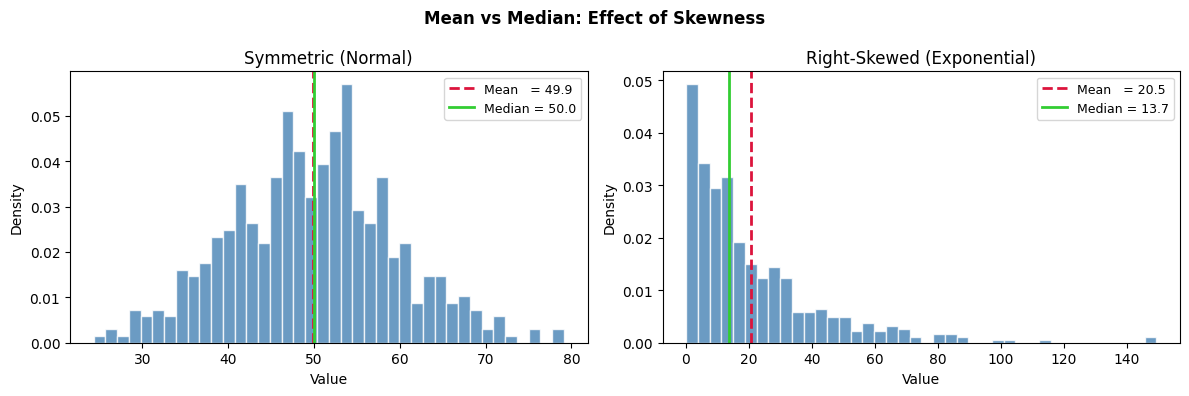

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, label in [
    (axes[0], symmetric, 'Symmetric (Normal)'),
    (axes[1], skewed,    'Right-Skewed (Exponential)'),
]:
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    ax.axvline(np.mean(data),   color='crimson', lw=2, ls='--',
               label=f'Mean   = {np.mean(data):.1f}')
    ax.axvline(np.median(data), color='limegreen', lw=2, ls='-',
               label=f'Median = {np.median(data):.1f}')
    ax.set_title(label)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Mean vs Median: Effect of Skewness', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## ML/AI Connection

- **Mean squared error (MSE)** minimisation produces predictions equal to the conditional **mean** — MSE-optimal predictions are always the expected value.
- **Mean absolute error (MAE)** minimisation produces the conditional **median** — more robust to outliers.
- **Feature scaling** (standardisation) centres features on their mean — essential for distance-based algorithms (KNN, SVM, PCA) and gradient descent convergence.
- **Target encoding** replaces a categorical variable with the mean target value for each category.
